# TD3 component ablation on `Ant-v5`

## Setup

In [ ]:
import copy
import pandas as pd
import td3_algorithm as algo   # our TD3 (now with a use_cdq flag, default True)
import config                  # ExperimentConfig + results-IO helpers
import training                # run_multi_seed driver
import plotting                # comparison plot + summary table
print('device:', algo.device)

device: cuda


## Base config + variants

In [ ]:
base_cfg = config.ExperimentConfig(
    env_id="Ant-v5",
    max_timesteps=1000000,
    start_timesteps=25000,
    eval_freq=5_000,
    results_dir="results/ablation",   # -> results/ablation/Ant-v5/logs
    snapshot_steps=[],             # no snapshots/videos for the ablation
)
SEEDS = [0, 1]

VARIANTS = [
    ("TD3",       {}),                                            # all three on (full method)
    ("TD3-noCDQ", {"use_cdq": False}),                            # - clipped double-Q
    ("TD3-noTPS", {"policy_noise": 0.0, "noise_clip": 0.0}),      # - target policy smoothing
    ("TD3-noDP",  {"policy_freq": 1}),                            # - delayed policy updates
    ("AHE",       {"use_cdq": False, "policy_noise": 0.0,         # none of the three
                    "noise_clip": 0.0, "policy_freq": 1}),
]
[v[0] for v in VARIANTS]

['TD3', 'TD3-noCDQ', 'TD3-noTPS', 'TD3-noDP', 'AHE']

## Run every variant

In [ ]:
dfs = []
for label, overrides in VARIANTS:
    vcfg = copy.deepcopy(base_cfg)
    vcfg.algorithm = label
    for k, val in overrides.items():
        setattr(vcfg, k, val)
    print(f'=== {label} === policy_freq={vcfg.policy_freq}, '
          f'policy_noise={vcfg.policy_noise}, noise_clip={vcfg.noise_clip}, use_cdq={vcfg.use_cdq}')
    dfs.append(training.run_multi_seed(vcfg, SEEDS))

df_ablation = pd.concat(dfs, ignore_index=True)
df_ablation.tail()

=== TD3 === policy_freq=2, policy_noise=0.2, noise_clip=0.5, use_cdq=True
Run: TD3_Ant-v5_seed0 | state_dim=105, action_dim=8, max_action=1.0 | snapshots at []
Eval | T=    5000 | Return=   982.240 | Elapsed=15.1s
Eval | T=   10000 | Return=   982.240 | Elapsed=31.2s
Eval | T=   15000 | Return=   982.240 | Elapsed=46.3s
Eval | T=   20000 | Return=   982.240 | Elapsed=61.9s
Eval | T=   25000 | Return=   982.240 | Elapsed=77.1s
Eval | T=   30000 | Return=   502.214 | Elapsed=146.9s
Eval | T=   35000 | Return=   430.639 | Elapsed=217.4s
Eval | T=   40000 | Return=    82.961 | Elapsed=271.0s
Eval | T=   45000 | Return=   176.720 | Elapsed=327.9s
Eval | T=   50000 | Return=   224.287 | Elapsed=389.4s
Eval | T=   55000 | Return=   205.732 | Elapsed=449.3s
Eval | T=   60000 | Return=   217.612 | Elapsed=492.5s
Eval | T=   65000 | Return=   525.084 | Elapsed=529.2s
Eval | T=   70000 | Return=   241.433 | Elapsed=561.8s
Eval | T=   75000 | Return=   410.995 | Elapsed=597.3s
Eval | T=   80000 | 

,timestep,episode,eval_return,episode_return,critic_loss,actor_loss,algorithm,env_id,seed
20901,999399,2627,NaN,132.831615,27.109680,-132.881073,AHE,Ant-v5,1
20902,999475,2628,NaN,150.849859,32.263687,-131.890900,AHE,Ant-v5,1
20903,999525,2629,NaN,72.991930,41.691444,-128.087738,AHE,Ant-v5,1
20904,999570,2630,NaN,70.841967,27.111511,-121.256119,AHE,Ant-v5,1
20905,1000000,2630,48.953612,NaN,24.716974,-125.175537,AHE,Ant-v5,1


## Learning curves

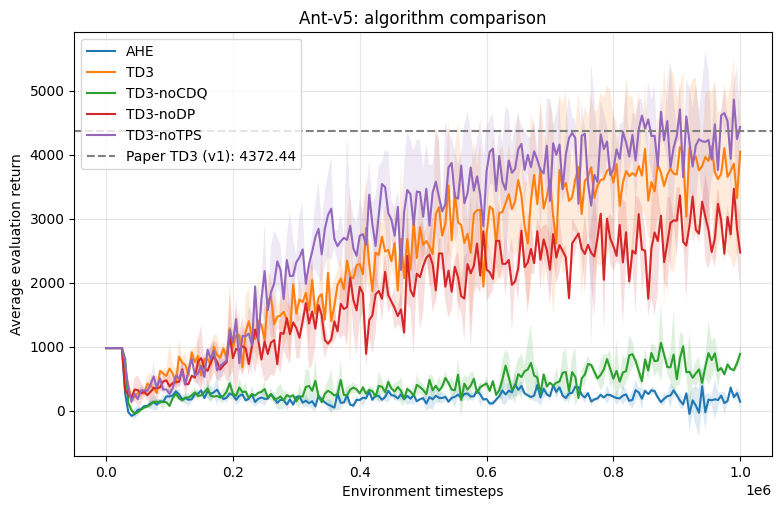

In [ ]:
plotting.plot_compare(df_ablation, base_cfg.env_id)

## Table 2-style summary

In [ ]:
per_seed = plotting.summarize(df_ablation)
display(per_seed)

# Average over seeds -> one row per variant, ordered like the paper (full TD3 first)
order = ['TD3', 'TD3-noCDQ', 'TD3-noTPS', 'TD3-noDP', 'AHE']
table2 = (per_seed.groupby('algorithm', as_index=False)
          .agg(max_return_mean=('max_return', 'mean'),
               last10_mean=('last10_avg', 'mean')))
table2['__o'] = table2['algorithm'].apply(lambda a: order.index(a) if a in order else 99)
table2 = table2.sort_values('__o').drop(columns='__o').reset_index(drop=True)
table2

,algorithm,env_id,seed,max_return,last10_avg,paper_td3_v1
0,TD3-noTPS,Ant-v5,1,5196.208041,4574.839190,4372.44
1,TD3,Ant-v5,0,5027.462185,4623.433999,4372.44
2,TD3-noTPS,Ant-v5,0,4655.279460,4105.540546,4372.44
3,TD3-noDP,Ant-v5,0,3691.178224,2846.684825,4372.44
4,TD3,Ant-v5,1,3588.205909,2954.200963,4372.44
5,TD3-noDP,Ant-v5,1,3506.613872,2830.138533,4372.44
6,TD3-noCDQ,Ant-v5,0,1487.082710,683.246564,4372.44
7,TD3-noCDQ,Ant-v5,1,1367.483713,755.062845,4372.44
8,AHE,Ant-v5,0,982.240462,157.184153,4372.44
9,AHE,Ant-v5,1,976.025718,245.980814,4372.44


,algorithm,max_return_mean,last10_mean
0,TD3,4307.834047,3788.817481
1,TD3-noCDQ,1427.283212,719.154704
2,TD3-noTPS,4925.743750,4340.189868
3,TD3-noDP,3598.896048,2838.411679
4,AHE,979.133090,201.582483
